In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
matches = pd.read_csv("../data/matches.csv")
deliveries = pd.read_csv("../data/deliveries.csv")

print(matches.head())
print(deliveries.head())

       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \
0        Kolkat

In [3]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  method           21 non-n

In [4]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [5]:
print("Total Seasons:", 
      matches["season"].nunique())

Total Seasons: 17


## EDA 1 : Team Analysis

In [6]:
teams = pd.concat([matches["team1"], matches["team2"]])
matches_played = teams.value_counts()
print(matches_played)

Mumbai Indians                 261
Kolkata Knight Riders          251
Royal Challengers Bangalore    240
Chennai Super Kings            238
Rajasthan Royals               221
Kings XI Punjab                190
Sunrisers Hyderabad            182
Delhi Daredevils               161
Delhi Capitals                  91
Deccan Chargers                 75
Punjab Kings                    56
Pune Warriors                   46
Gujarat Titans                  45
Lucknow Super Giants            44
Gujarat Lions                   30
Rising Pune Supergiant          16
Royal Challengers Bengaluru     15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64


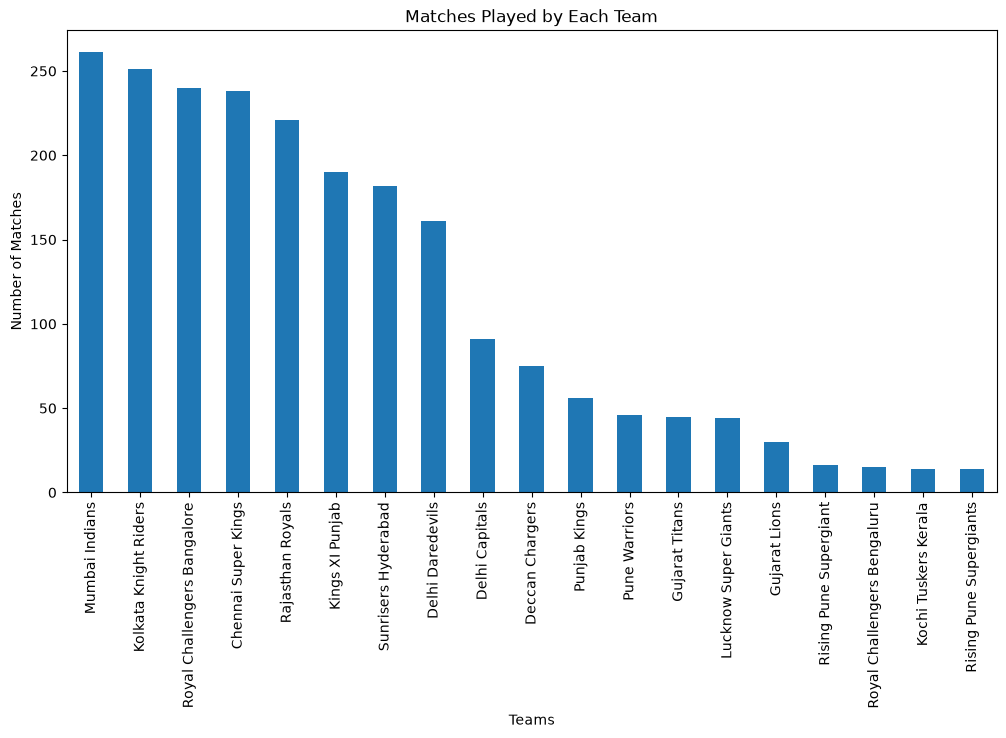

In [7]:
plt.figure(figsize=(12,6))

matches_played.plot(kind="bar")

plt.title("Matches Played by Each Team")
plt.xlabel("Teams")
plt.ylabel("Number of Matches")

plt.xticks(rotation=90)

plt.show()

In [8]:
team_wins = matches["winner"].value_counts()
team_wins

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

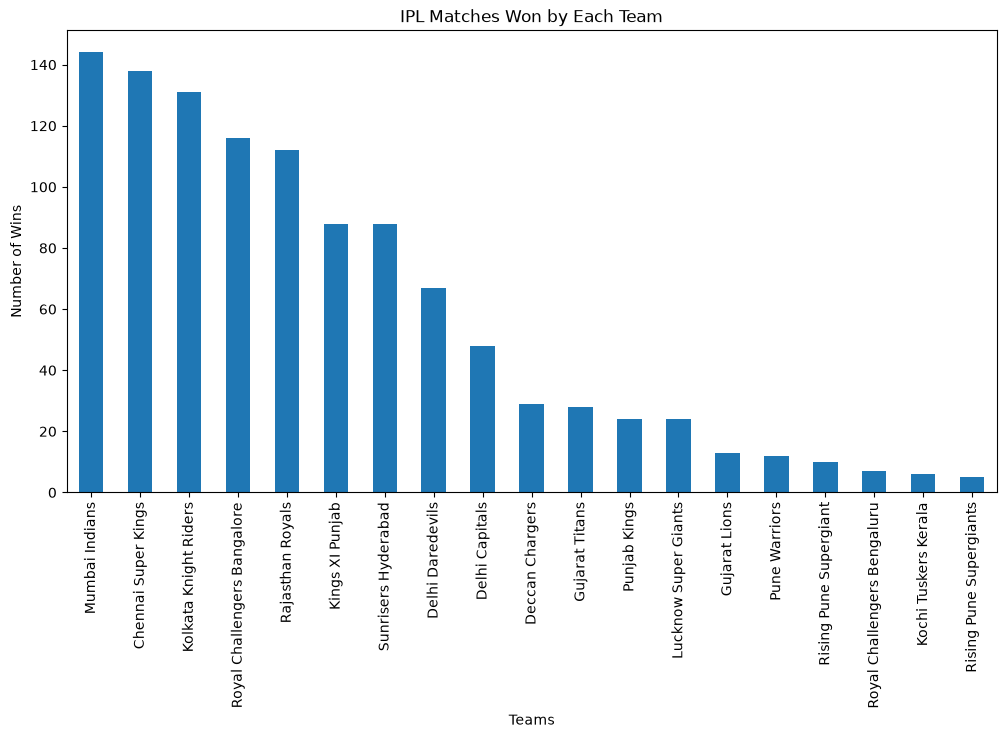

In [9]:
plt.figure(figsize=(12,6))

team_wins.plot(kind="bar")

plt.title("IPL Matches Won by Each Team")
plt.xlabel("Teams")
plt.ylabel("Number of Wins")

plt.xticks(rotation=90)

plt.show()

In [10]:
team_wins.head(10)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64

In [11]:
print("Most Successful Team:")
print(team_wins.idxmax())
print("Wins:", team_wins.max())

Most Successful Team:
Mumbai Indians
Wins: 144


## EDA 2 : Win Analysis

In [12]:
# =======Team Winning Percentage===== #

matches_played = pd.concat([matches["team1"], matches["team2"]]).value_counts() #Matches Played
matches_won = matches["winner"].value_counts() #Matched Won

team_stats = pd.DataFrame({
    "Matches Played": matches_played,
    "Matches Won": matches_won
})

team_stats = team_stats.fillna(0) #If the match has no result or the cell is empty

team_stats["Win Percentage"] = (
    team_stats["Matches Won"] /
    team_stats["Matches Played"]
) * 100

team_stats["Win Percentage"] = team_stats["Win Percentage"].round(2) #roundoff values

team_stats.sort_values(by="Win Percentage", ascending=False)

,Matches Played,Matches Won,Win Percentage
Rising Pune Supergiant,16,10,62.50
Gujarat Titans,45,28,62.22
Chennai Super Kings,238,138,57.98
Mumbai Indians,261,144,55.17
Lucknow Super Giants,44,24,54.55
Delhi Capitals,91,48,52.75
Kolkata Knight Riders,251,131,52.19
Rajasthan Royals,221,112,50.68
Sunrisers Hyderabad,182,88,48.35
Royal Challengers Bangalore,240,116,48.33


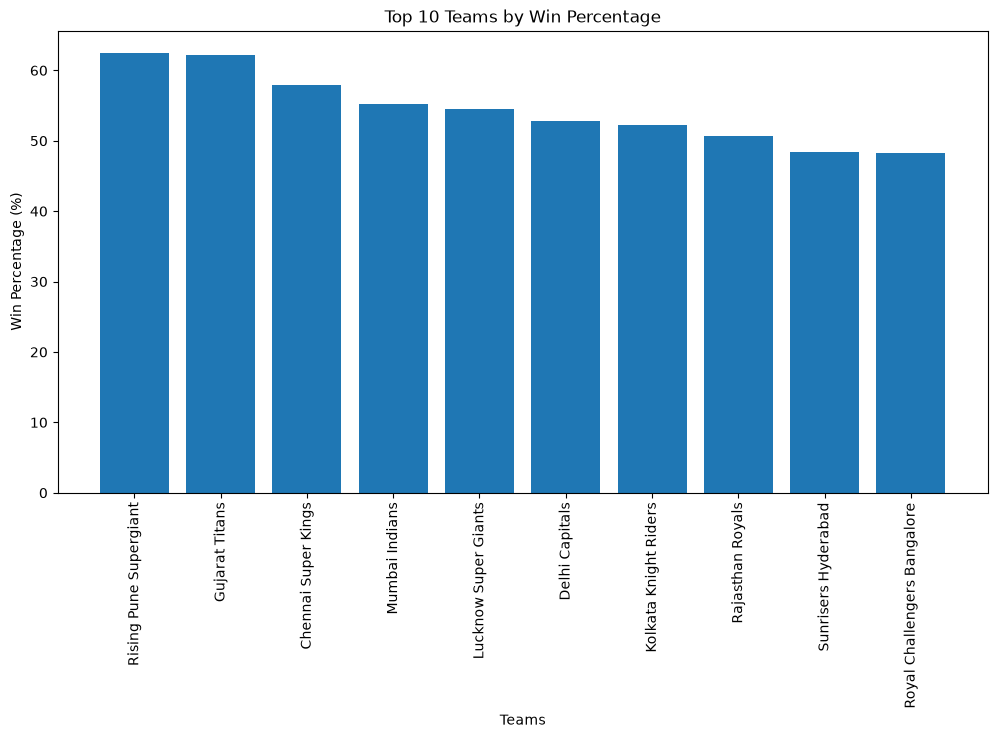

In [13]:
top10 = team_stats.sort_values(
    by="Win Percentage",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(top10.index, top10["Win Percentage"])

plt.title("Top 10 Teams by Win Percentage")
plt.xlabel("Teams")
plt.ylabel("Win Percentage (%)")

plt.xticks(rotation=90)

plt.show()

## EDA 3 : Orange Cap Analysis

In [14]:
# =======Orange Cap Analysis======#

batter_runs = deliveries.groupby("batter")["batsman_runs"].sum()
batter_runs.head()

batter_runs = batter_runs.sort_values(ascending=False)
batter_runs.head(10)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64

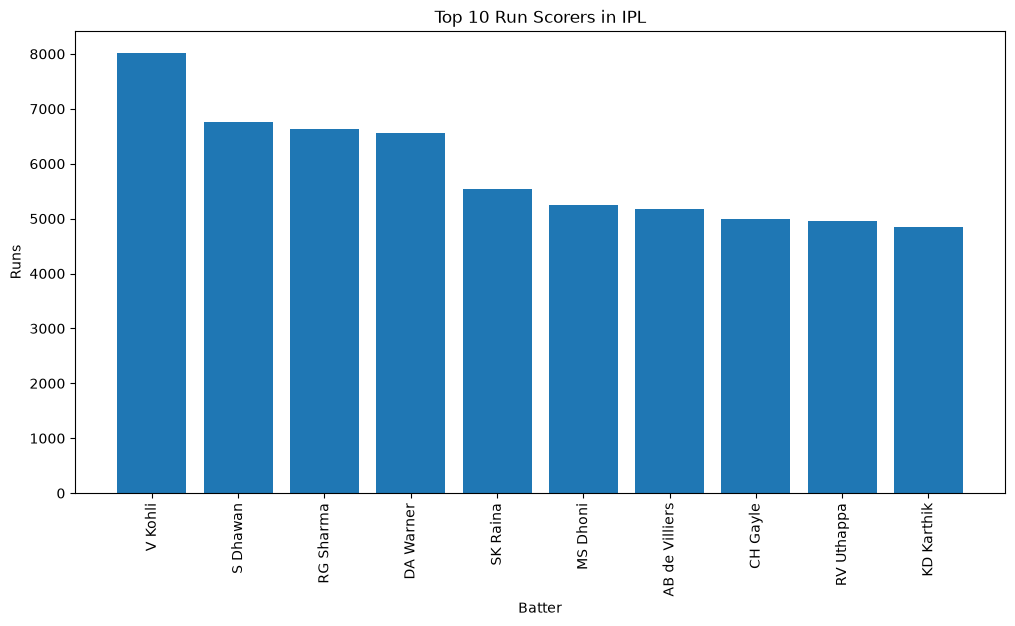

In [15]:
top10_batters = batter_runs.head(10)
plt.figure(figsize=(12,6))
plt.bar(top10_batters.index, top10_batters.values)

plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Batter")
plt.ylabel("Runs")

plt.xticks(rotation=90)

plt.show()

## EDA 4 : Player with Most Sixes 

In [16]:
# ======Players with Most Sixes======= #

sixes = deliveries[deliveries["batsman_runs"] == 6]

most_sixes = sixes["batter"].value_counts()
most_sixes.head(10)

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
Name: count, dtype: int64

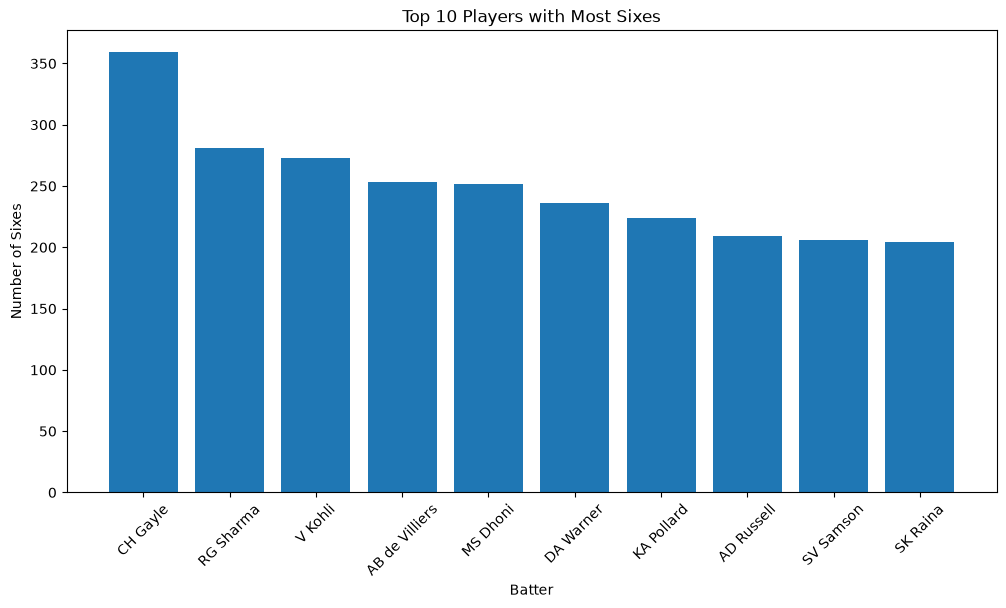

In [17]:
plt.figure(figsize=(12,6))

plt.bar(most_sixes.head(10).index, most_sixes.head(10).values)

plt.title("Top 10 Players with Most Sixes")
plt.xlabel("Batter")
plt.ylabel("Number of Sixes")

plt.xticks(rotation=45)

plt.show()

## EDA 5 : Toss Impact Analysis


In [18]:
# =======Toss Impact Analysis=====#

matches["toss_win_match_win"] = matches["toss_winner"] == matches["winner"]

matches["toss_win_match_win"].value_counts()

toss_percentage = (
    matches["toss_win_match_win"]
    .value_counts(normalize=True) * 100
)

print(toss_percentage)

toss_win_match_win
True     50.593607
False    49.406393
Name: proportion, dtype: float64


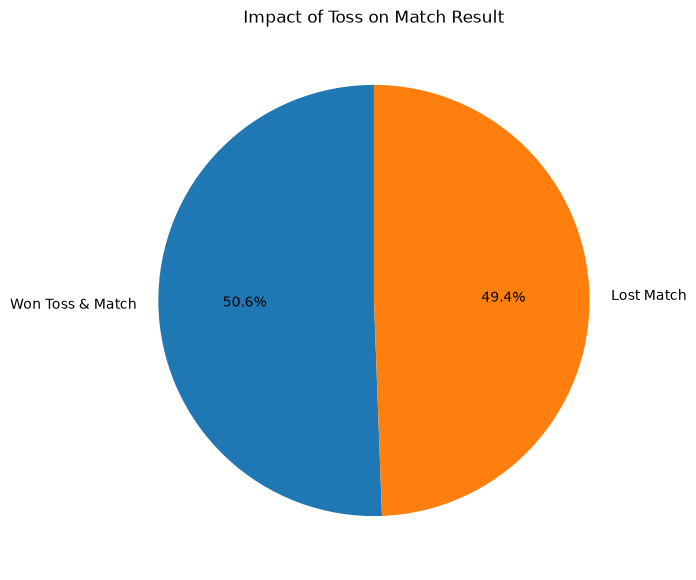

In [19]:
plt.figure(figsize=(7,7))

plt.pie(
    toss_percentage,
    labels=["Won Toss & Match", "Lost Match"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Impact of Toss on Match Result")

plt.show()

## EDA 6 : Venue Analysis

In [20]:
venue_matches = matches["venue"].value_counts()
venue_matches.head(10)

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64

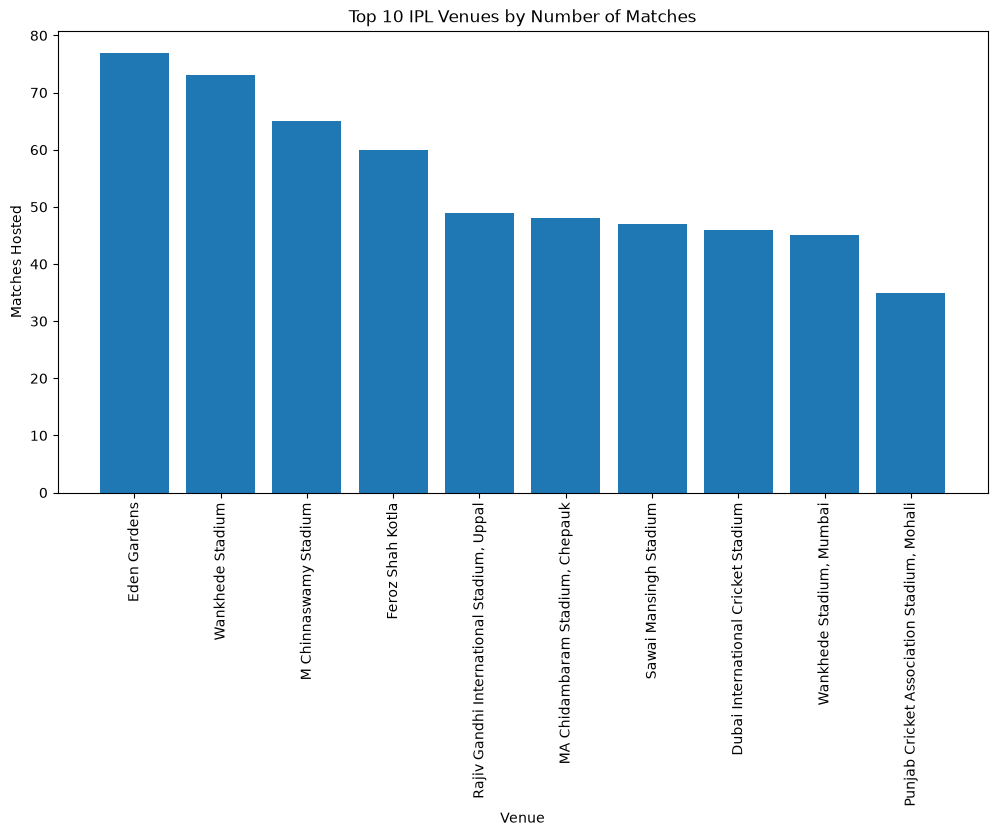

In [21]:
plt.figure(figsize=(12,6))

plt.bar(venue_matches.head(10).index,
        venue_matches.head(10).values)

plt.title("Top 10 IPL Venues by Number of Matches")

plt.xlabel("Venue")

plt.ylabel("Matches Hosted")

plt.xticks(rotation=90)

plt.show()

In [22]:
city_matches = matches["city"].value_counts()
city_matches.head(10)

city
Mumbai        173
Kolkata        93
Delhi          90
Chennai        85
Hyderabad      77
Bangalore      65
Chandigarh     61
Jaipur         57
Pune           51
Abu Dhabi      37
Name: count, dtype: int64

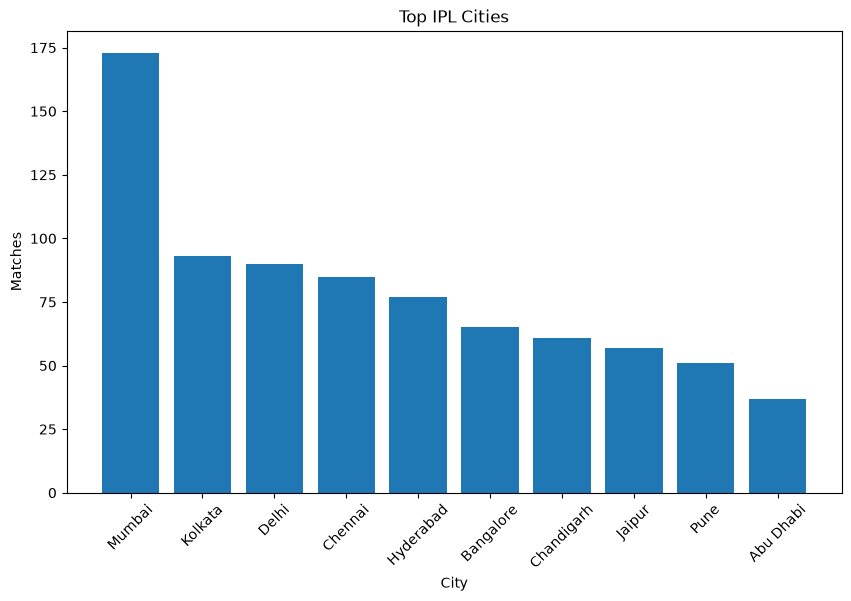

In [23]:
plt.figure(figsize=(10,6))

plt.bar(city_matches.head(10).index,
        city_matches.head(10).values)

plt.title("Top IPL Cities")
plt.xlabel("City")
plt.ylabel("Matches")

plt.xticks(rotation=45)

plt.show()

In [24]:
innings_score = deliveries.groupby(
    ["match_id","inning"]
)["total_runs"].sum().reset_index()

venue_score = innings_score.merge(
    matches[["id","venue"]],
    left_on="match_id",
    right_on="id"
)

avg_score = venue_score.groupby(
    "venue"
)["total_runs"].mean().sort_values(ascending=False)

avg_score.head(10)

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam    200.000000
Arun Jaitley Stadium, Delhi                                           190.343750
Eden Gardens, Kolkata                                                 190.156250
M Chinnaswamy Stadium, Bengaluru                                      190.071429
Himachal Pradesh Cricket Association Stadium, Dharamsala              189.375000
Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh      185.600000
Rajiv Gandhi International Stadium, Uppal, Hyderabad                  182.423077
Brabourne Stadium                                                     174.050000
Punjab Cricket Association IS Bindra Stadium                          173.800000
Wankhede Stadium, Mumbai                                              173.188889
Name: total_runs, dtype: float64

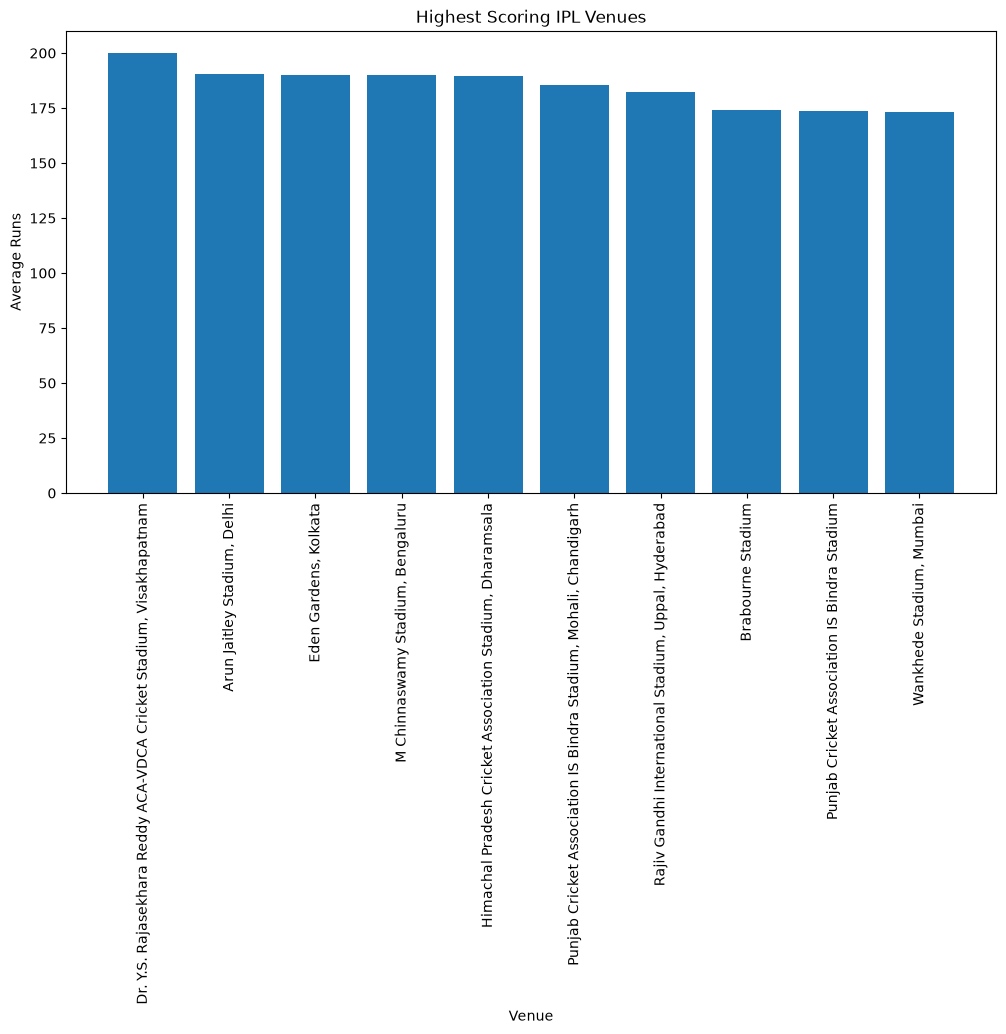

In [25]:
plt.figure(figsize=(12,6))

plt.bar(avg_score.head(10).index,
        avg_score.head(10).values)

plt.title("Highest Scoring IPL Venues")

plt.xlabel("Venue")
plt.ylabel("Average Runs")
plt.xticks(rotation=90)

plt.show()

In [26]:
player = "MS Dhoni"
dhoni = deliveries[deliveries["batter"] == player]
dhoni.head()

runs = dhoni["batsman_runs"].sum()
balls = dhoni.shape[0]
strike_rate = (runs/balls)*100
print(strike_rate)

len(dhoni[dhoni["batsman_runs"]==4])
len(dhoni[dhoni["batsman_runs"]==6])

player_data = deliveries.merge(
    matches[["id","season"]],
    left_on="match_id",
    right_on="id"
)

dhoni = player_data[player_data["batter"]=="MS Dhoni"]

season_runs = dhoni.groupby("season")["batsman_runs"].sum()

season_runs

132.8350646060299


season
2007/08    414
2009       332
2009/10    287
2011       392
2012       358
2013       461
2014       371
2015       372
2016       284
2017       290
2018       455
2019       416
2020/21    200
2021       114
2022       232
2023       104
2024       161
Name: batsman_runs, dtype: int64

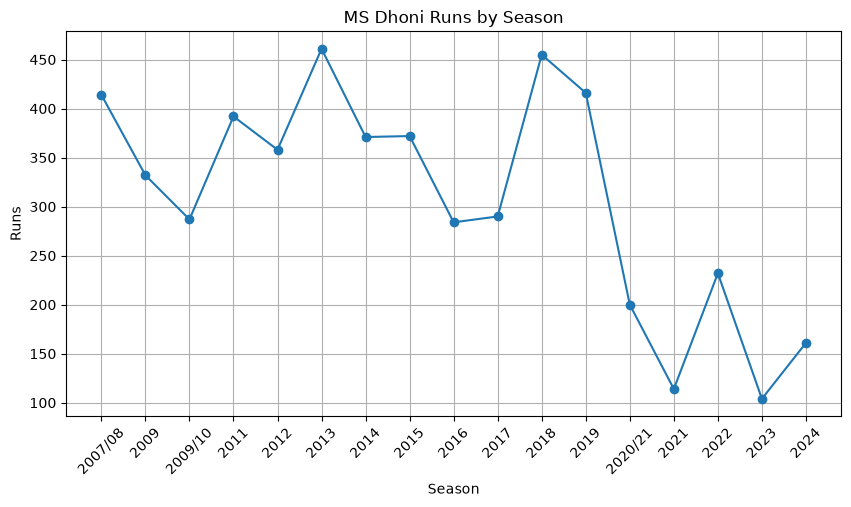

In [27]:
plt.figure(figsize=(10,5))

plt.plot(
    season_runs.index,
    season_runs.values,
    marker="o"
)

plt.title("MS Dhoni Runs by Season")

plt.xlabel("Season")

plt.ylabel("Runs")

plt.grid()
plt.xticks(rotation = 45)
plt.show()

## EDA 8 : Purple Cap Analysis

In [28]:
deliveries["dismissal_kind"].value_counts()
valid_wickets = deliveries[(~deliveries["dismissal_kind"].isin([
    "run out",
    "retired hurt",
    "obstructing the field",
    "retired out"
]))
&
(deliveries["dismissal_kind"].notna())
]

top_bowlers = valid_wickets["bowler"].value_counts()

top_bowlers.head(10)

bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
R Ashwin      180
SP Narine     180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
Name: count, dtype: int64

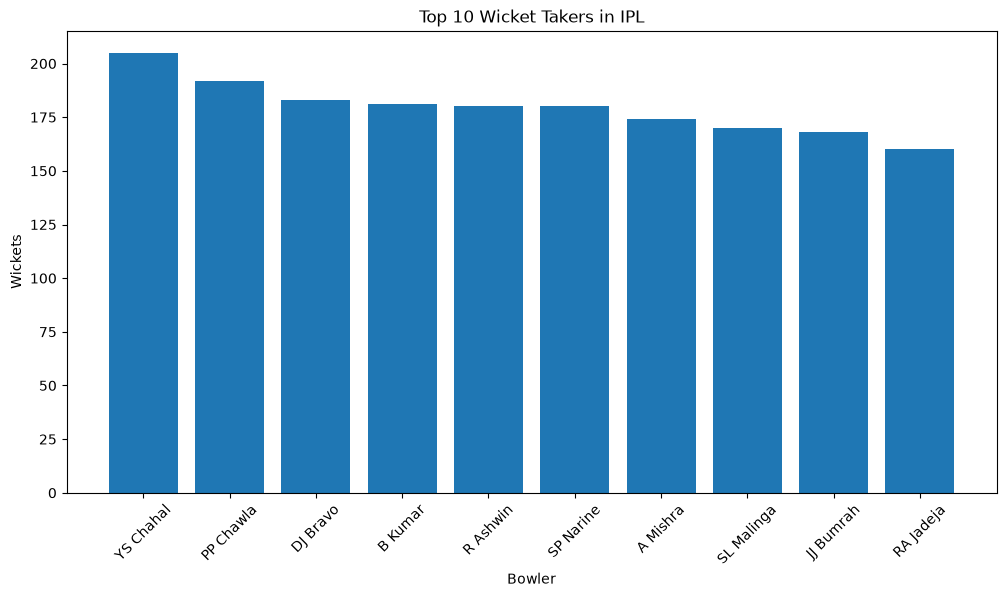

In [29]:
plt.figure(figsize=(12,6))

plt.bar(
    top_bowlers.head(10).index,
    top_bowlers.head(10).values
)

plt.title("Top 10 Wicket Takers in IPL")
plt.xlabel("Bowler")
plt.ylabel("Wickets")

plt.xticks(rotation=45)

plt.show()

## EDA 9 : Economy Rate

In [31]:
# Runs conceded by each bowler
runs_conceded = deliveries.groupby("bowler")["total_runs"].sum()

runs_conceded.head()

legal_balls = deliveries[
    (deliveries["extras_type"] != "wides") &
    (deliveries["extras_type"] != "noballs")
]
balls_bowled = legal_balls.groupby("bowler").size()

balls_bowled.head()

overs = balls_bowled / 6

overs.head()

economy_df = pd.DataFrame({
    "Runs Conceded": runs_conceded,
    "Balls Bowled": balls_bowled,
    "Overs": overs
})
economy_df = economy_df.dropna()


economy_df["Economy"] = (
    economy_df["Runs Conceded"] /
    economy_df["Overs"]
)

economy_df.head()

economy_df = economy_df[economy_df["Overs"] >= 100]

best_economy = economy_df.sort_values(
    by="Economy"
)

best_economy.head(10)

,Runs Conceded,Balls Bowled,Overs,Economy
bowler,,,,
A Kumble,1089,965,160.833333,6.770984
SP Narine,4672,4081,680.166667,6.868905
DL Vettori,894,777,129.500000,6.903475
M Muralitharan,1765,1528,254.666667,6.930628
Rashid Khan,3340,2872,478.666667,6.977716
J Botha,818,694,115.666667,7.072046
DW Steyn,2583,2182,363.666667,7.102658
R Sharma,1100,928,154.666667,7.112069
MM Ali,900,758,126.333333,7.124011


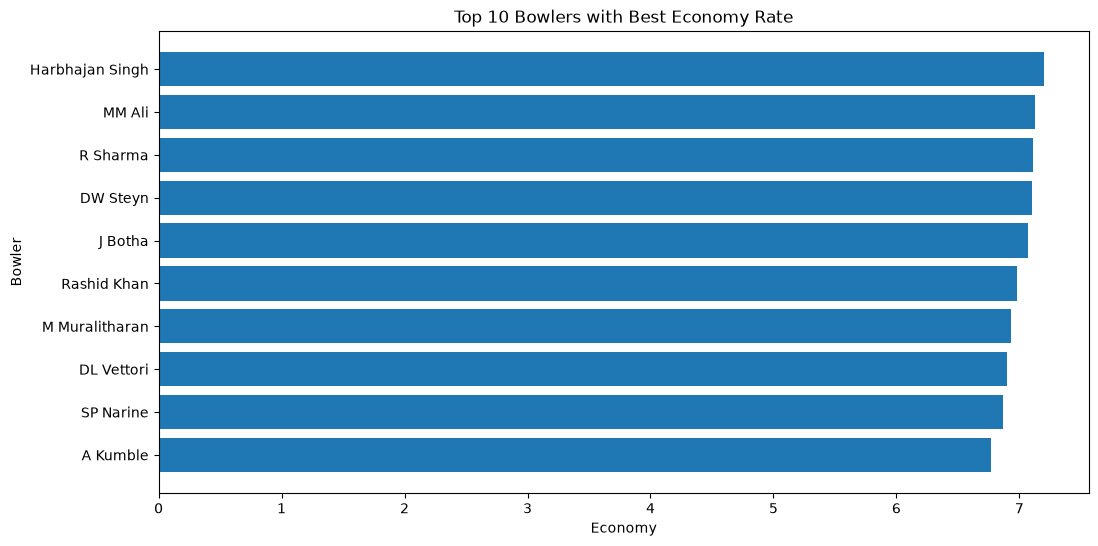

In [32]:
plt.figure(figsize=(12,6))

plt.barh(
    best_economy.head(10).index,
    best_economy.head(10)["Economy"]
)

plt.title("Top 10 Bowlers with Best Economy Rate")
plt.xlabel("Economy")
plt.ylabel("Bowler")

plt.show()

## EDA 10 : Head to Head Comaprison

In [45]:

# Calculate innings scores once (outside the function)
innings_scores = deliveries.groupby(
    ["match_id", "inning", "batting_team"]
)["total_runs"].sum().reset_index()


def head_to_head(team1, team2):

    # Filter matches played between the two teams
    h2h = matches[
        (
            (matches["team1"] == team1) &
            (matches["team2"] == team2)
        )
        |
        (
            (matches["team1"] == team2) &
            (matches["team2"] == team1)
        )
    ]

    if h2h.empty:
        print("No matches found between these two teams.")
        return

    # Heading
    print("=" * 70)
    print("HEAD TO HEAD ANALYSIS".center(70))
    print("=" * 70)
    print(f"{team1}  🆚  {team2}".center(70))
    print("=" * 70)

    # Total Matches
    total_matches = h2h.shape[0]
    print(f"\n🏏 Total Matches Played : {total_matches}")

    # Wins
    wins = h2h["winner"].value_counts()

    print("\n🏆 Match Wins")
    print("-" * 35)
    print(wins)

    # Win Percentage
    print("\n📊 Win Percentage")
    print("-" * 35)

    for team in [team1, team2]:
        team_wins = wins.get(team, 0)
        percentage = (team_wins / total_matches) * 100
        print(f"{team:<35} {percentage:.2f}%")

    # Toss Winners
    print("\n🪙 Toss Winners")
    print("-" * 35)
    print(h2h["toss_winner"].value_counts())

    # Venues
    print("\n🏟 Top Venues")
    print("-" * 35)
    print(h2h["venue"].value_counts().head())

    # Highest Team Scores
    team_scores = innings_scores[
        (
            (innings_scores["batting_team"] == team1)
            |
            (innings_scores["batting_team"] == team2)
        )
        &
        (
            innings_scores["match_id"].isin(h2h["id"])
        )
    ]

    print("\n💥 Highest Team Score")
    print("-" * 35)
    print(team_scores.groupby("batting_team")["total_runs"].max())

    # Average Team Score
    print("\n📈 Average Team Score")
    print("-" * 35)
    print(team_scores.groupby("batting_team")["total_runs"].mean().round(2))

    # --------------------------
    # Visualization
    # --------------------------

    plt.figure(figsize=(8,5))

    plt.bar(
        wins.index,
        wins.values
    )

    plt.title(f"{team1} vs {team2}")

    plt.xlabel("Team")

    plt.ylabel("Wins")

    plt.grid(axis="y")

    plt.show()

                        HEAD TO HEAD ANALYSIS                         
                Mumbai Indians  🆚  Chennai Super Kings                

🏏 Total Matches Played : 37

🏆 Match Wins
-----------------------------------
winner
Mumbai Indians         20
Chennai Super Kings    17
Name: count, dtype: int64

📊 Win Percentage
-----------------------------------
Mumbai Indians                      54.05%
Chennai Super Kings                 45.95%

🪙 Toss Winners
-----------------------------------
toss_winner
Mumbai Indians         19
Chennai Super Kings    18
Name: count, dtype: int64

🏟 Top Venues
-----------------------------------
venue
Wankhede Stadium                       9
MA Chidambaram Stadium, Chepauk        5
Wankhede Stadium, Mumbai               3
Eden Gardens                           2
Dubai International Cricket Stadium    2
Name: count, dtype: int64

💥 Highest Team Score
-----------------------------------
batting_team
Chennai Super Kings    218
Mumbai Indians         219


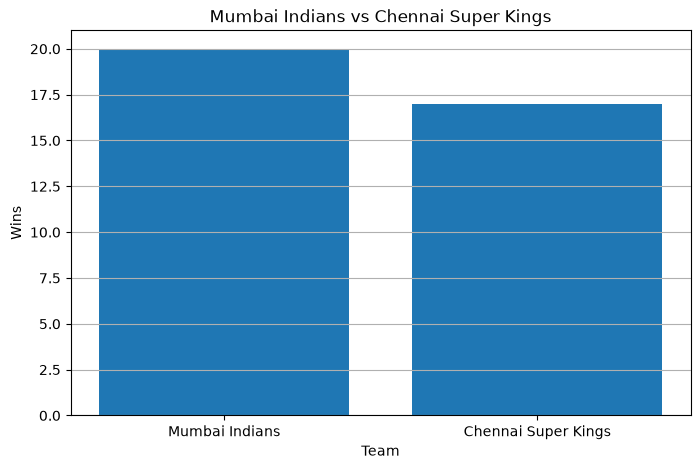

In [46]:
head_to_head("Mumbai Indians", "Chennai Super Kings")